In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
# Feature: data.data, Target: data.target

df = pd.DataFrame(data.data)
df['target'] = data.target

#print(df.info())

#print(df.head())

print(df.corr()['target'].sort_values(ascending=False))

target    1.000000
14        0.067016
9         0.012838
11        0.008303
18        0.006522
19       -0.077972
16       -0.253730
15       -0.292999
29       -0.323872
8        -0.330499
4        -0.358560
17       -0.408042
1        -0.415185
28       -0.416294
24       -0.421465
21       -0.456903
13       -0.548236
12       -0.556141
10       -0.567134
25       -0.590998
5        -0.596534
26       -0.659610
6        -0.696360
3        -0.708984
0        -0.730029
23       -0.733825
2        -0.742636
20       -0.776454
7        -0.776614
22       -0.782914
27       -0.793566
Name: target, dtype: float64


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

model = LogisticRegression()
scaler = StandardScaler()

exclude = ['target']
features = df.drop(columns=exclude)

X_train, X_test, y_train, y_test = train_test_split(features, df['target'], test_size=0.3, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
model.score(X_test_scaled, y_test)

0.9824561403508771

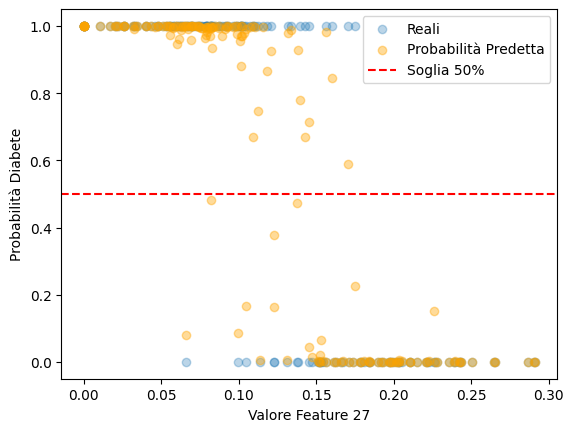

In [ ]:
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test_scaled)[:, 1] 

# 1. Plot dei valori REALI (i punti blu a 0 e 1)
plt.scatter(X_test[27], y_test, alpha=0.3, label='Reali')

# 2. Plot delle PREVISIONI (i punti arancioni che mostrano la probabilità)
# Usiamo X_test[27] per l'asse X (valori originali) e le probabilità per l'asse Y
plt.scatter(X_test[27], y_probs, color='orange', alpha=0.4, label='Probabilità Predetta')

# 3. Linea di soglia decisionale a 0.5
plt.axhline(0.5, color='red', linestyle='--', label='Soglia 50%')

plt.xlabel('Valore Feature 27')
plt.ylabel('Probabilità Diabete')
plt.legend()
plt.show()

[[ 62   1]
 [  2 106]]


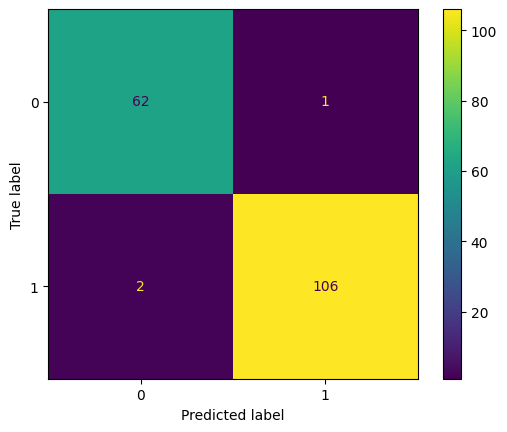

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, model.predict(X_test_scaled)))
disp.plot()

print(confusion_matrix(y_test, model.predict(X_test_scaled)))